# 06 — Deep Community Analysis
## Network Structures, User Archetypes, and Behavioral Patterns in Trump vs AOC Reply Sections

While previous notebooks analyzed *what* the politicians post and *how much* engagement they receive, this notebook shifts focus to the **community itself** — the people who reply. Using netnographic methodology (Kozinets, 2015), we examine:

- **Reply network topology**: Who mentions whom in the reply sections?
- **Opinion leaders**: Which repliers drive conversation?
- **Community clusters**: Are there distinct behavioral groups?
- **User archetypes**: Supporters, critics, trolls, and bots
- **Conversation depth**: How deep do reply threads go?
- **Longitudinal behavior**: How does engagement evolve over time?
- **Cross-profile engagement**: Do the same users engage with both politicians?

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets, load_replies, load_user_profiles, load_mention_network
from utils.plot_helpers import setup_style, get_colors, get_user_label, format_large_numbers
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED, ARCHETYPE_COLORS

setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

In [2]:
df = load_tweets()
replies_df = load_replies()
profiles = load_user_profiles()
mention_edges = load_mention_network()

print(f"\nDataset summary:")
print(f"  Tweets: {len(df)}")
print(f"  Replies: {len(replies_df)}")
print(f"  Unique repliers profiled: {len(profiles)}")
print(f"  Mention network edges: {len(mention_edges)}")

Loaded 200 tweets from processed/
Loaded 11403 replies from processed/
Loaded 7980 user profiles from processed/
Loaded 5036 mention edges from processed/

Dataset summary:
  Tweets: 200
  Replies: 11403
  Unique repliers profiled: 7980
  Mention network edges: 5036


---
## 1. The Reply Network: Who Talks to Whom?

Network overview:
  Nodes: 4,395
  Edges: 5,036
  Density: 0.000261
  Avg in-degree: 1.15
  Avg out-degree: 1.15


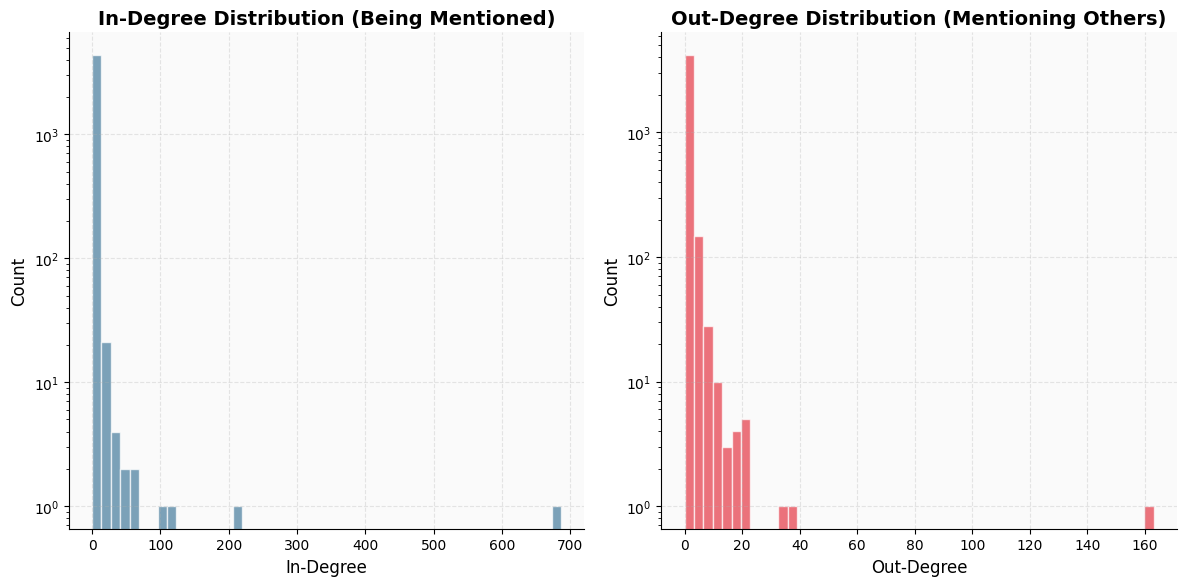

In [3]:
# Build NetworkX directed graph from mention edges
G = nx.DiGraph()
for _, row in mention_edges.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

print(f"Network overview:")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"  Density: {nx.density(G):.6f}")
print(f"  Avg in-degree: {np.mean([d for _, d in G.in_degree()]):.2f}")
print(f"  Avg out-degree: {np.mean([d for _, d in G.out_degree()]):.2f}")

# Degree distributions
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

axes[0].hist(in_degrees, bins=50, color=colors['aoc'], alpha=0.7, edgecolor='white')
axes[0].set_title('In-Degree Distribution (Being Mentioned)', fontweight='bold')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

axes[1].hist(out_degrees, bins=50, color=colors['trump'], alpha=0.7, edgecolor='white')
axes[1].set_title('Out-Degree Distribution (Mentioning Others)', fontweight='bold')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

**What does this tell us?** The degree distributions follow a power-law pattern — most users mention (or are mentioned by) very few others, while a small number of users serve as network hubs. This is typical of online political communities where a few vocal participants dominate the conversation structure.

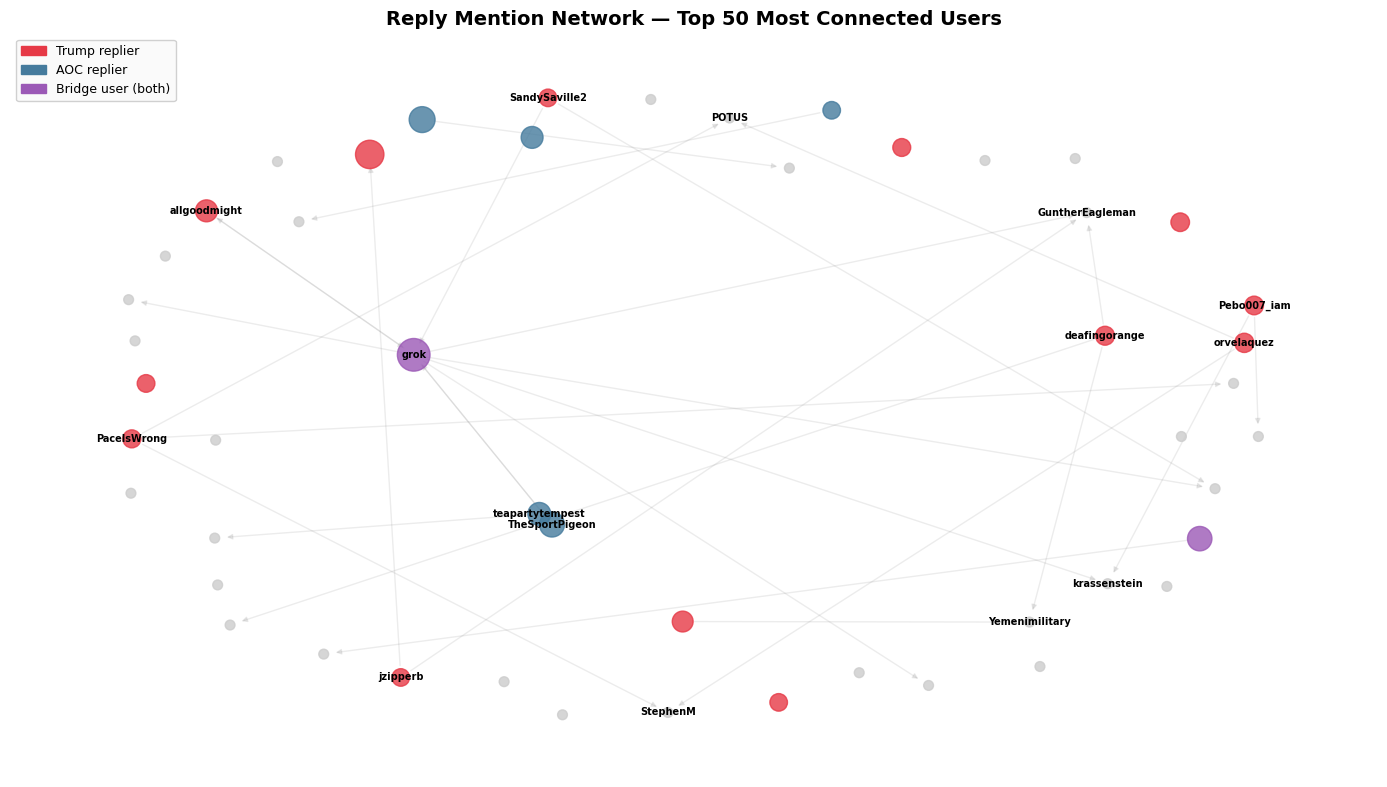

In [4]:
# Network visualization: top 50 most-connected nodes
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:50]
subG = G.subgraph(top_nodes)

# Map nodes to their primary politician
profiles_map = profiles.set_index('user_name')
node_colors_map = []
node_sizes = []
for node in subG.nodes():
    if node in profiles_map.index:
        p = profiles_map.loc[node]
        if p.get('is_cross_profile', False):
            node_colors_map.append('#9B59B6')  # purple for bridge
        elif p.get('trump_replies', 0) > p.get('aoc_replies', 0):
            node_colors_map.append(colors['trump'])
        else:
            node_colors_map.append(colors['aoc'])
        followers = max(p.get('user_followers_count', 100), 100)
        node_sizes.append(min(np.log10(followers) * 80, 800))
    else:
        node_colors_map.append('#CCCCCC')
        node_sizes.append(50)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_LARGE)
pos = nx.spring_layout(subG, seed=RANDOM_SEED, k=2)

nx.draw_networkx_edges(subG, pos, alpha=0.15, edge_color='gray',
                        arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors_map,
                        node_size=node_sizes, alpha=0.8, ax=ax)

# Label top 15 nodes
top_15 = sorted(subG.nodes(), key=lambda n: subG.degree(n), reverse=True)[:15]
labels = {n: n for n in top_15}
nx.draw_networkx_labels(subG, pos, labels, font_size=7, font_weight='bold', ax=ax)

legend_patches = [
    mpatches.Patch(color=colors['trump'], label='Trump replier'),
    mpatches.Patch(color=colors['aoc'], label='AOC replier'),
    mpatches.Patch(color='#9B59B6', label='Bridge user (both)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title('Reply Mention Network — Top 50 Most Connected Users', fontweight='bold', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

**What does this tell us?** The network visualization reveals the community structure within each politician's reply section. Node size reflects follower count (influence), while color shows which politician the user primarily engages with. Bridge users (purple) who engage with both are rare — a visual representation of political echo chambers.

---
## 2. Opinion Leaders: Who Drives the Conversation?

In [5]:
# Centrality analysis
pagerank = nx.pagerank(G, weight='weight')
betweenness = nx.betweenness_centrality(G, weight='weight', k=min(500, G.number_of_nodes()))

centrality_df = pd.DataFrame({
    'user_name': list(pagerank.keys()),
    'pagerank': list(pagerank.values()),
    'betweenness': [betweenness.get(n, 0) for n in pagerank.keys()],
    'in_degree': [G.in_degree(n) for n in pagerank.keys()],
    'out_degree': [G.out_degree(n) for n in pagerank.keys()],
})

# Merge with profile data
centrality_df = centrality_df.merge(
    profiles[['user_name', 'user_followers_count', 'archetype', 'trump_replies', 'aoc_replies']],
    on='user_name', how='left'
)
centrality_df['primary_politician'] = np.where(
    centrality_df['trump_replies'].fillna(0) > centrality_df['aoc_replies'].fillna(0),
    'Trump', 'AOC'
)

# Show top 15 opinion leaders by PageRank
top_leaders = centrality_df.nlargest(15, 'pagerank')[
    ['user_name', 'primary_politician', 'user_followers_count', 'pagerank',
     'in_degree', 'archetype']
].reset_index(drop=True)
top_leaders.index += 1
top_leaders.columns = ['User', 'Primary', 'Followers', 'PageRank', 'In-Degree', 'Archetype']
top_leaders['PageRank'] = top_leaders['PageRank'].apply(lambda x: f"{x:.5f}")
top_leaders['Followers'] = top_leaders['Followers'].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else 'N/A')

print("Top 15 Opinion Leaders by PageRank:")
display(top_leaders)

Top 15 Opinion Leaders by PageRank:


,User,Primary,Followers,PageRank,In-Degree,Archetype
1,SenateDems,AOC,N/A,0.06751,686,NaN
2,DianaforQueens,AOC,N/A,0.02572,219,NaN
3,grok,Trump,"8,104,538",0.01492,114,casual
4,SenSchumer,AOC,N/A,0.00573,107,NaN
5,F15Synch,AOC,N/A,0.00492,44,NaN
6,Yemenimilitary,AOC,N/A,0.00442,55,NaN
7,GuntherEagleman,AOC,N/A,0.00367,57,NaN
8,krassenstein,AOC,N/A,0.00345,42,NaN
9,StephenM,AOC,N/A,0.00337,30,NaN
10,allgoodmight,Trump,"1,342",0.00302,12,casual


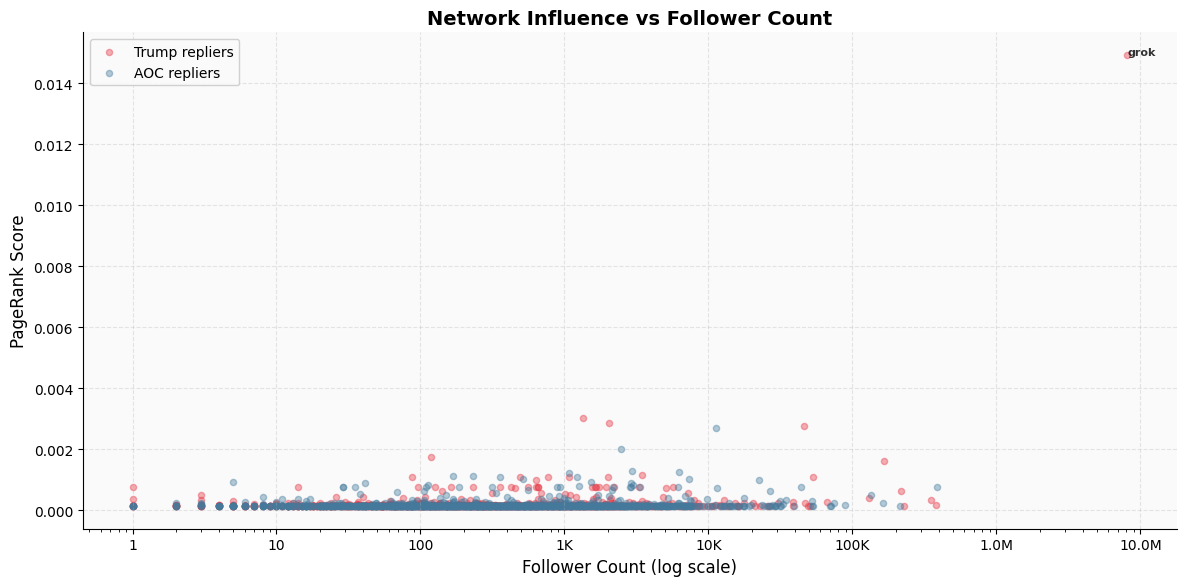

In [6]:
# Followers vs PageRank scatter
plot_df = centrality_df[centrality_df['user_followers_count'].notna()].copy()
plot_df = plot_df[plot_df['user_followers_count'] > 0]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
for pol, color in [('Trump', colors['trump']), ('AOC', colors['aoc'])]:
    mask = plot_df['primary_politician'] == pol
    ax.scatter(plot_df[mask]['user_followers_count'], plot_df[mask]['pagerank'],
              alpha=0.4, color=color, label=f'{pol} repliers', s=20)

# Label top 5
for _, row in centrality_df.nlargest(5, 'pagerank').iterrows():
    if row['user_name'] in plot_df['user_name'].values:
        ax.annotate(row['user_name'],
                   (row['user_followers_count'], row['pagerank']),
                   fontsize=8, fontweight='bold', alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Follower Count (log scale)')
ax.set_ylabel('PageRank Score')
ax.set_title('Network Influence vs Follower Count', fontweight='bold')
ax.legend()
format_large_numbers(ax, 'x')
plt.tight_layout()
plt.show()

**What does this tell us?** PageRank measures actual influence *within the reply network*, while follower count measures external social capital. Users with high PageRank but low followers are community-specific influencers — people who may not be famous but are central to the political discourse in these reply threads. Conversely, high-follower users with low PageRank are famous people who don't generate much in-reply conversation.

---
## 3. Community Clusters: Are There Distinct Groups?

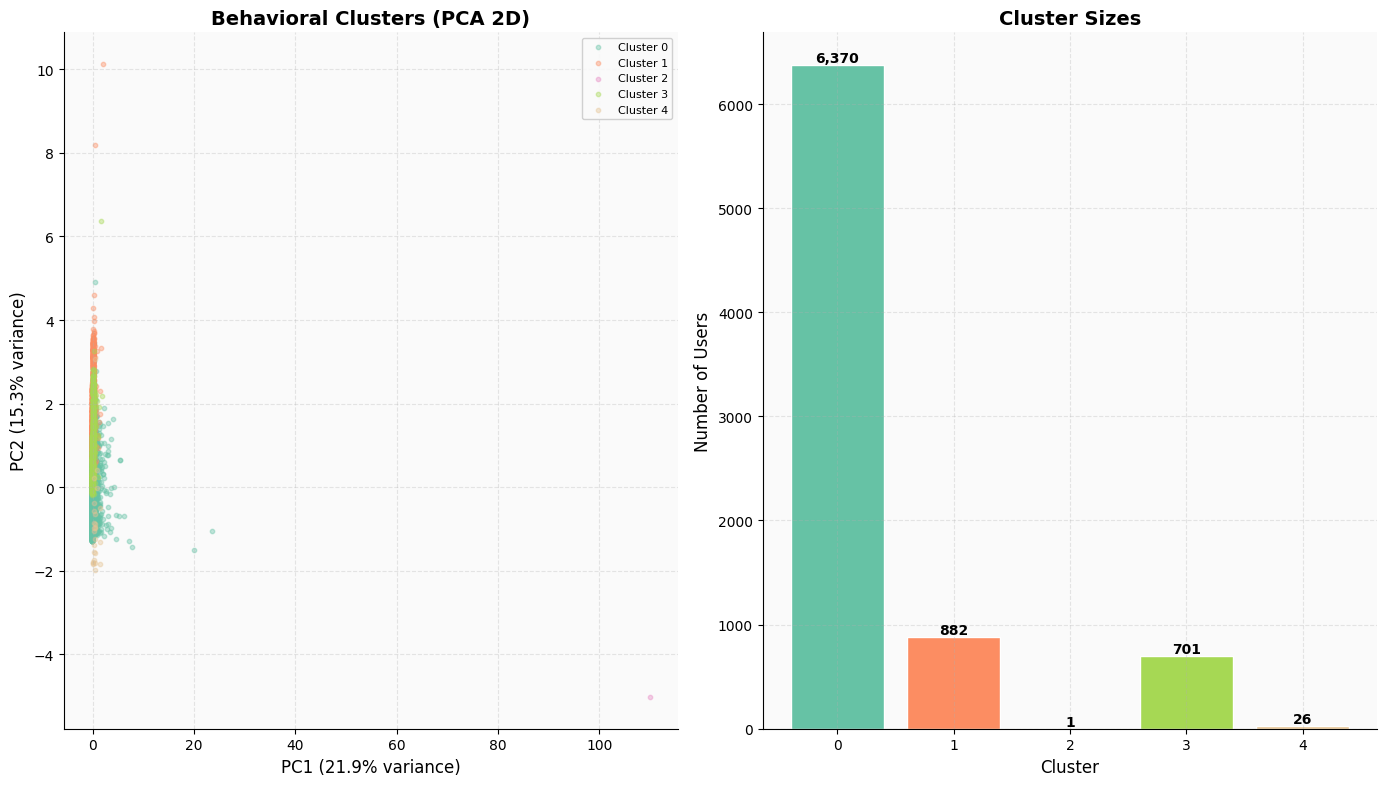

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA on behavioral features for 2D visualization
feature_cols = [
    'total_replies', 'avg_text_length', 'avg_favorites_received',
    'user_followers_count', 'negative_pct', 'positive_pct',
    'mentions_parent_pct', 'avg_reply_delay_minutes',
]
X = profiles[feature_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

# Left: colored by cluster
cluster_cmap = plt.cm.Set2
for cluster_id in sorted(profiles['behavior_cluster'].unique()):
    mask = profiles['behavior_cluster'] == cluster_id
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                   alpha=0.4, s=10, label=f'Cluster {cluster_id}',
                   color=cluster_cmap(cluster_id / 5))
axes[0].set_title('Behavioral Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend(fontsize=8)

# Right: cluster sizes
cluster_sizes = profiles['behavior_cluster'].value_counts().sort_index()
bars = axes[1].bar(cluster_sizes.index, cluster_sizes.values,
                   color=[cluster_cmap(i/5) for i in cluster_sizes.index],
                   edgecolor='white')
for bar, val in zip(bars, cluster_sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
               f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Cluster Sizes', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

In [8]:
# Cluster comparison table
cluster_stats = profiles.groupby('behavior_cluster').agg(
    users=('user_name', 'count'),
    avg_replies=('total_replies', 'mean'),
    avg_followers=('user_followers_count', 'mean'),
    avg_favorites=('avg_favorites_received', 'mean'),
    avg_text_length=('avg_text_length', 'mean'),
    positive_pct=('positive_pct', 'mean'),
    negative_pct=('negative_pct', 'mean'),
).round(2)

cluster_stats.columns = ['Users', 'Avg Replies', 'Avg Followers', 'Avg Favorites',
                          'Avg Text Length', 'Positive %', 'Negative %']
print("Cluster behavioral profiles:")
display(cluster_stats)

# Cluster vs politician cross-tab
print("\nCluster distribution by primary politician:")
profiles['primary_politician'] = np.where(
    profiles['trump_replies'] > profiles['aoc_replies'], 'Trump', 'AOC'
)
cross_tab = pd.crosstab(profiles['behavior_cluster'], profiles['primary_politician'],
                         normalize='index').round(3) * 100
cross_tab.columns = [f'{c} %' for c in cross_tab.columns]
display(cross_tab)

Cluster behavioral profiles:


,Users,Avg Replies,Avg Followers,Avg Favorites,Avg Text Length,Positive %,Negative %
behavior_cluster,,,,,,,
0,6370,1.44,1445.21,0.36,93.58,0.01,0.01
1,882,1.20,1204.78,0.40,154.83,0.00,0.95
2,1,233.00,8104538.00,0.18,272.87,0.08,0.06
3,701,1.22,1497.86,0.49,147.37,0.93,0.01
4,26,2.27,5079.77,0.38,93.98,0.11,0.06



Cluster distribution by primary politician:


,AOC %,Trump %
behavior_cluster,,
0,42.8,57.2
1,57.8,42.2
2,0.0,100.0
3,33.0,67.0
4,19.2,80.8


**What does this tell us?** The KMeans clustering reveals naturally occurring behavioral groups. The largest cluster represents typical, low-activity repliers, while smaller clusters capture high-engagement users, prolific commenters, or users with distinctive behavioral patterns. The cross-tabulation reveals whether certain behavioral profiles are more prevalent in one politician's reply section.

---
## 4. User Archetypes: Supporters, Critics, Trolls, and Bots

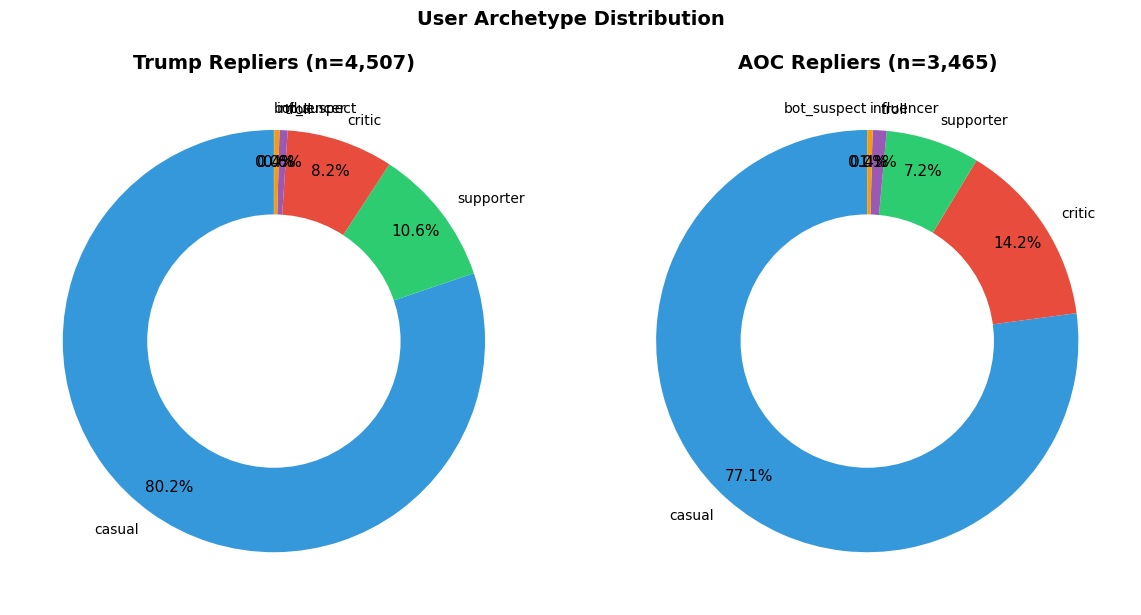

In [9]:
# Archetype distribution per politician
trump_profiles = profiles[profiles['trump_replies'] > profiles['aoc_replies']]
aoc_profiles = profiles[profiles['aoc_replies'] > profiles['trump_replies']]

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for ax, p_df, title in [
    (axes[0], trump_profiles, f"Trump Repliers (n={len(trump_profiles):,})"),
    (axes[1], aoc_profiles, f"AOC Repliers (n={len(aoc_profiles):,})"),
]:
    arch_counts = p_df['archetype'].value_counts()
    arch_colors = [ARCHETYPE_COLORS.get(a, '#999') for a in arch_counts.index]

    wedges, texts, autotexts = ax.pie(
        arch_counts.values, labels=arch_counts.index,
        colors=arch_colors, autopct='%1.1f%%',
        pctdistance=0.85, startangle=90
    )
    # Draw circle for donut
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    ax.add_artist(centre_circle)
    ax.set_title(title, fontweight='bold')

plt.suptitle('User Archetype Distribution', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Archetype behavioral fingerprints:


,Count,Avg Replies,Avg Text Length,Avg Favorites,Avg Delay (min),Avg Hashtags,Mentions Parent %,Avg Followers
archetype,,,,,,,,
bot_suspect,1,40.00,42.58,0.00,24239.70,0.00,1.0,87.00
casual,6291,1.47,94.06,0.34,53371.57,0.07,1.0,2486.95
critic,863,1.22,152.53,0.36,40204.31,0.04,1.0,1021.65
influencer,32,1.16,107.98,7.69,39408.44,0.09,1.0,74100.69
supporter,728,1.24,145.23,0.40,65543.13,0.05,1.0,835.63
troll,65,1.40,93.86,0.27,25218.84,0.05,1.0,745.45


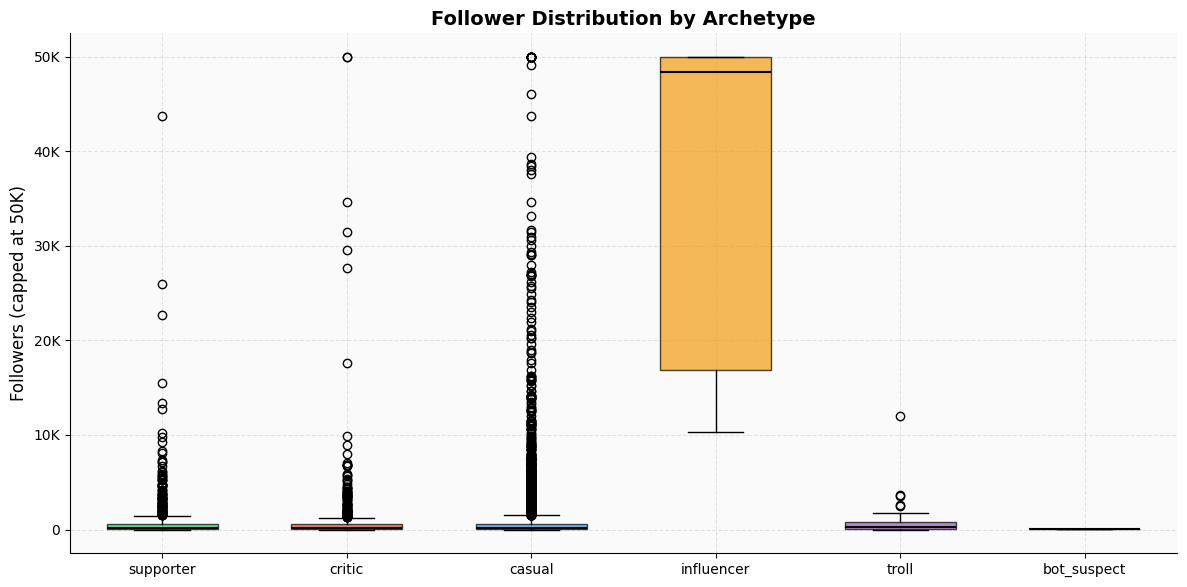

In [10]:
# Archetype behavioral fingerprints
arch_features = profiles.groupby('archetype').agg(
    count=('user_name', 'count'),
    avg_replies=('total_replies', 'mean'),
    avg_text_length=('avg_text_length', 'mean'),
    avg_favorites=('avg_favorites_received', 'mean'),
    avg_delay_min=('avg_reply_delay_minutes', 'mean'),
    avg_hashtags=('avg_hashtag_count', 'mean'),
    mentions_parent_pct=('mentions_parent_pct', 'mean'),
    avg_followers=('user_followers_count', 'mean'),
).round(2)

arch_features.columns = ['Count', 'Avg Replies', 'Avg Text Length', 'Avg Favorites',
                          'Avg Delay (min)', 'Avg Hashtags', 'Mentions Parent %', 'Avg Followers']
print("Archetype behavioral fingerprints:")
display(arch_features)

# Box plots: followers per archetype
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
arch_order = ['supporter', 'critic', 'casual', 'influencer', 'troll', 'bot_suspect']
arch_order = [a for a in arch_order if a in profiles['archetype'].values]

data_by_arch = [profiles[profiles['archetype'] == a]['user_followers_count'].clip(upper=50000)
                for a in arch_order]

bp = ax.boxplot(data_by_arch, labels=arch_order, patch_artist=True, widths=0.6,
               medianprops={'color': 'black', 'linewidth': 1.5})
for patch, arch in zip(bp['boxes'], arch_order):
    patch.set_facecolor(ARCHETYPE_COLORS.get(arch, '#999'))
    patch.set_alpha(0.7)

ax.set_title('Follower Distribution by Archetype', fontweight='bold')
ax.set_ylabel('Followers (capped at 50K)')
format_large_numbers(ax)
plt.tight_layout()
plt.show()

In [11]:
# Representative reply examples per archetype
print("Representative replies per archetype:\n")
for arch in ['supporter', 'critic', 'troll', 'influencer', 'bot_suspect']:
    arch_users = profiles[profiles['archetype'] == arch]['user_name'].values
    if len(arch_users) == 0:
        continue
    arch_replies = replies_df[replies_df['user_name'].isin(arch_users)]
    if arch_replies.empty:
        continue
    # Pick highest-engagement examples
    examples = arch_replies.nlargest(2, 'favorite_count')
    print(f"--- {arch.upper()} ---")
    for _, ex in examples.iterrows():
        text_preview = ex['text'][:150] + ('...' if len(str(ex['text'])) > 150 else '')
        print(f"  @{ex['user_name']} (replying to {ex['parent_user']}): \"{text_preview}\"")
        print(f"    Likes: {ex['favorite_count']:,} | Views: {ex['view_count']:,}")
    print()

Representative replies per archetype:

--- SUPPORTER ---
  @Wess_Miller (replying to aoc): "@AOC @DianaforQueens @AOC, thank you for leading from the front!

@DianaforQueens, wishing you the best of luck!"
    Likes: 8 | Views: 777
  @WitCephandrius (replying to aoc): "@DavidLHillPA @AOC She wasn't, you absolute retard. She was a locker room attendant. I swear Democrats are the dumbest people alive.

@grok Was Virgin..."
    Likes: 6 | Views: 465

--- CRITIC ---
  @Achilles440617 (replying to trump): "@realDonaldTrump POTUS @realDonaldTrump, any foolish decision that risks the lives of over 60K 🇺🇸 personnel for a criminal lunatic as @netanyahu who w..."
    Likes: 26 | Views: 10,130
  @existensil (replying to aoc): "@Bmmoody @AOC @DianaforQueens Even countries that run the public health programs poorly have far lower costs and better health outcomes than the US. Y..."
    Likes: 8 | Views: 69

--- TROLL ---
  @barbgrant236565 (replying to trump): "@realDonaldTrump LIES LIES LIES LIES L

=== THE GROK PHENOMENON ===
Grok (xAI's AI assistant) is active in both reply sections:

  Total replies: 233
  Trump replies: 197
  AOC replies: 36
  Archetype: casual
  Followers: 8,104,538
  Avg favorites per reply: 0.2
  Dominant sentiment: neutral


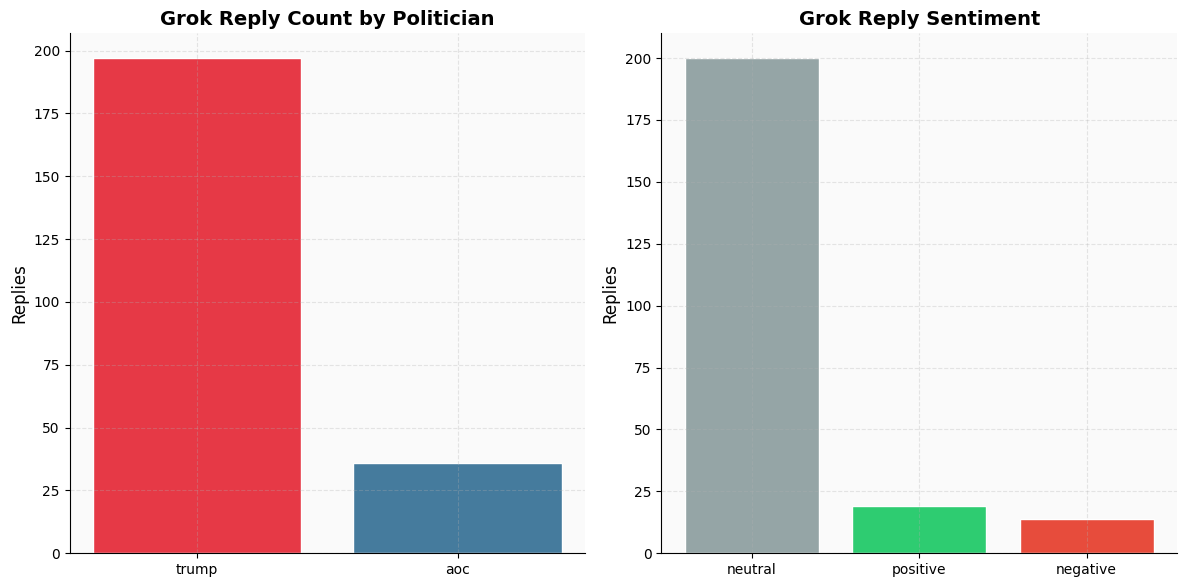

In [12]:
# The Grok phenomenon: AI bot as top replier
grok_profile = profiles[profiles['user_name'].str.lower() == 'grok']
grok_replies = replies_df[replies_df['user_name'].str.lower() == 'grok']

if not grok_profile.empty:
    print("=== THE GROK PHENOMENON ===")
    print(f"Grok (xAI's AI assistant) is active in both reply sections:\n")
    g = grok_profile.iloc[0]
    print(f"  Total replies: {g['total_replies']}")
    print(f"  Trump replies: {g['trump_replies']}")
    print(f"  AOC replies: {g['aoc_replies']}")
    print(f"  Archetype: {g['archetype']}")
    print(f"  Followers: {g['user_followers_count']:,.0f}")
    print(f"  Avg favorites per reply: {g['avg_favorites_received']:.1f}")
    print(f"  Dominant sentiment: {g['dominant_sentiment']}")

    # Grok activity over time
    if not grok_replies.empty:
        fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

        # Replies per politician
        grok_by_pol = grok_replies['parent_user'].value_counts()
        grok_colors = [colors.get(p, '#999') for p in grok_by_pol.index]
        axes[0].bar(grok_by_pol.index, grok_by_pol.values, color=grok_colors, edgecolor='white')
        axes[0].set_title('Grok Reply Count by Politician', fontweight='bold')
        axes[0].set_ylabel('Replies')

        # Sentiment distribution
        grok_sent = grok_replies['sentiment_simple'].value_counts()
        sent_colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#95A5A6'}
        axes[1].bar(grok_sent.index, grok_sent.values,
                   color=[sent_colors.get(s, '#999') for s in grok_sent.index],
                   edgecolor='white')
        axes[1].set_title('Grok Reply Sentiment', fontweight='bold')
        axes[1].set_ylabel('Replies')

        plt.tight_layout()
        plt.show()
else:
    print("Grok not found in replier dataset.")

**What does this tell us?** The archetype distribution reveals the composition of each politician's audience. The presence of AI bots like Grok participating in political discourse is a novel netnographic finding — it raises questions about the authenticity and organic nature of online political conversations. The behavioral fingerprints show that each archetype has distinctive patterns in how they write, when they reply, and how much engagement they receive.

---
## 5. Conversation Depth: Beyond First-Level Replies

Conversation depth overview:
  Users whose replies spawned sub-threads: 598 (7.5%)
  Total sub-replies generated: 1,548


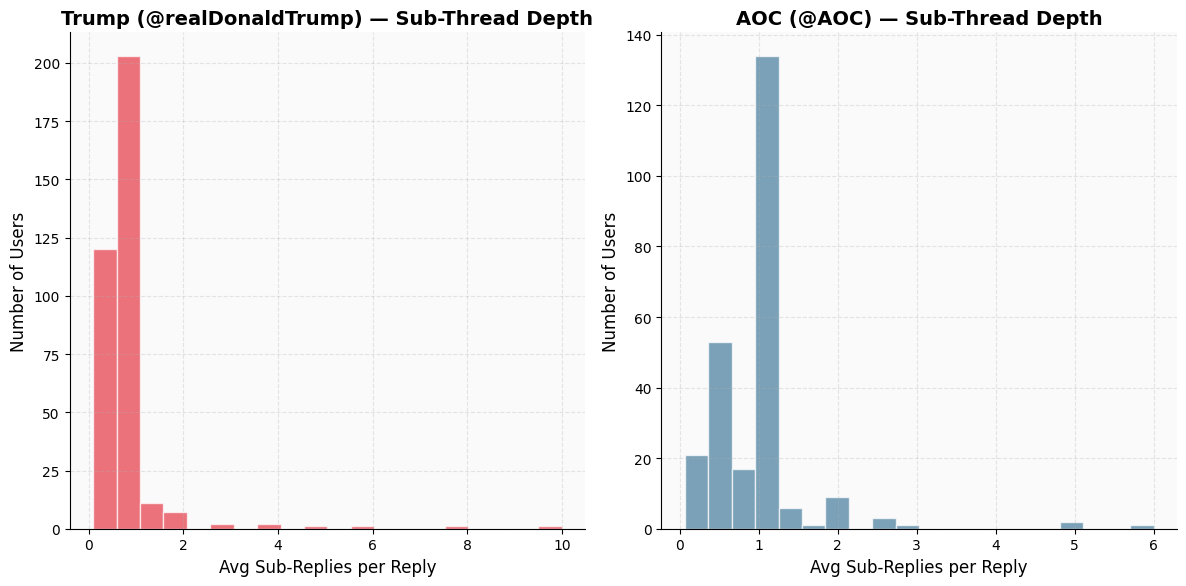

In [13]:
# Sub-thread analysis using reply_count from raw data
# replies_with_subreplies in profiles tells us how many of a user's replies spawned sub-threads

# Overall: what fraction of first-level replies spawn sub-conversations?
total_with_subreplies = (profiles['replies_with_subreplies'] > 0).sum()
total_subreply_volume = profiles['total_subreply_count'].sum()

print(f"Conversation depth overview:")
print(f"  Users whose replies spawned sub-threads: {total_with_subreplies:,} ({total_with_subreplies/len(profiles)*100:.1f}%)")
print(f"  Total sub-replies generated: {total_subreply_volume:,}")

# Compare Trump vs AOC thread depth
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

for ax, pol, color in [(axes[0], 'trump', colors['trump']), (axes[1], 'aoc', colors['aoc'])]:
    pol_profiles = profiles[profiles[f'{pol}_replies'] > profiles[('aoc' if pol == 'trump' else 'trump') + '_replies']]
    subreply_dist = pol_profiles['avg_subreply_count'].clip(upper=10)
    ax.hist(subreply_dist[subreply_dist > 0], bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{get_user_label(pol)} — Sub-Thread Depth', fontweight='bold')
    ax.set_xlabel('Avg Sub-Replies per Reply')
    ax.set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

In [14]:
# Reciprocal mention analysis: back-and-forth conversations
edges_set = set()
for _, row in mention_edges.iterrows():
    edges_set.add((row['source'], row['target']))

reciprocal_pairs = []
for _, row in mention_edges.iterrows():
    if (row['target'], row['source']) in edges_set:
        pair = tuple(sorted([row['source'], row['target']]))
        reciprocal_pairs.append(pair)

reciprocal_unique = set(reciprocal_pairs)
total_edges = len(mention_edges)

print(f"\nConversation reciprocity:")
print(f"  Total directed mention edges: {total_edges:,}")
print(f"  Reciprocal pairs (A↔B): {len(reciprocal_unique):,}")
print(f"  Reciprocity rate: {len(reciprocal_unique)*2/total_edges*100:.1f}%")

if reciprocal_unique:
    print(f"\n  Top reciprocal pairs (back-and-forth conversations):")
    # Score by combined weight
    pair_weights = {}
    for a, b in reciprocal_unique:
        w1 = mention_edges[(mention_edges['source']==a) & (mention_edges['target']==b)]['weight'].sum()
        w2 = mention_edges[(mention_edges['source']==b) & (mention_edges['target']==a)]['weight'].sum()
        pair_weights[(a,b)] = w1 + w2

    for (a, b), w in sorted(pair_weights.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"    {a} ↔ {b} (combined mentions: {w})")


Conversation reciprocity:
  Total directed mention edges: 5,036
  Reciprocal pairs (A↔B): 258
  Reciprocity rate: 10.2%

  Top reciprocal pairs (back-and-forth conversations):


    Darealynsny ↔ TheSportPigeon (combined mentions: 79)
    GerryRiver55569 ↔ teapartytempest (combined mentions: 62)
    TheSportPigeon ↔ TokyoRobb (combined mentions: 62)
    Jaythewolf1 ↔ TheSportPigeon (combined mentions: 56)
    allgoodmight ↔ grok (combined mentions: 48)
    TheSportPigeon ↔ grok (combined mentions: 47)
    muy_bro89458 ↔ sheluvvmikeyyyy (combined mentions: 44)
    PopTartsdSmores ↔ teapartytempest (combined mentions: 33)
    Darealynsny ↔ Jaythewolf1 (combined mentions: 33)
    5CYBJo3cm50uSxR ↔ grok (combined mentions: 30)


**What does this tell us?** Most first-level replies are one-way messages that don't generate further discussion. The reciprocity rate reveals how much *actual dialogue* occurs in the reply sections versus monologue-style commenting. Low reciprocity suggests that most people are talking *at* the politician or *at* each other rather than *with* each other.

---
## 6. How Engagement Evolves Over Time

Repeat repliers (5+ replies): 200 users, 2109 replies


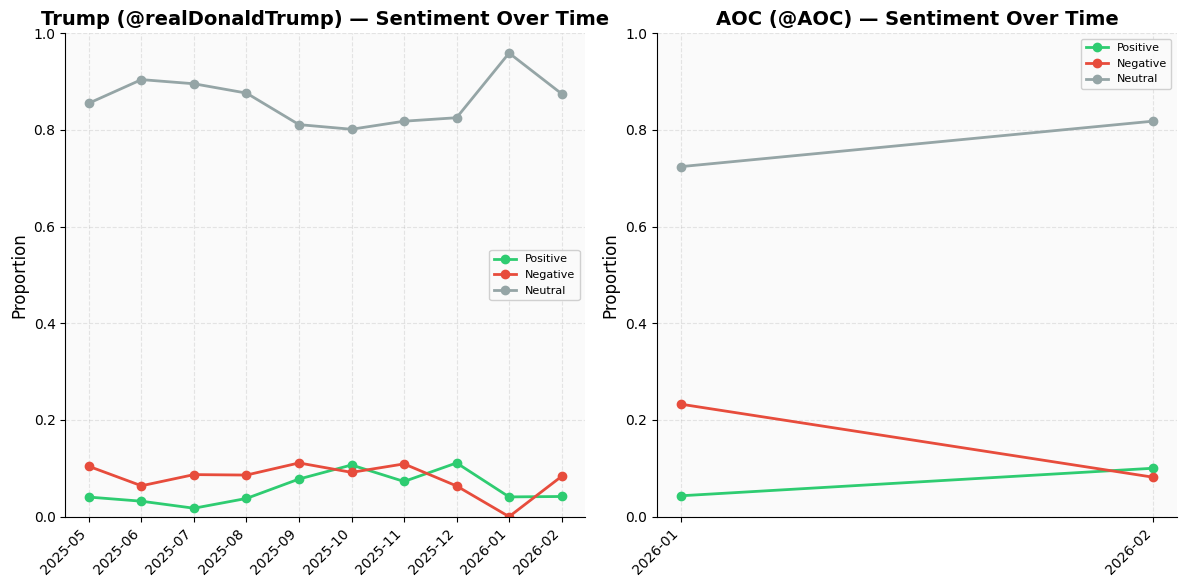

In [15]:
# Temporal engagement patterns for repeat repliers
repeat_users = profiles[profiles['total_replies'] >= 5]['user_name'].values
repeat_replies = replies_df[replies_df['user_name'].isin(repeat_users)].copy()

print(f"Repeat repliers (5+ replies): {len(repeat_users)} users, {len(repeat_replies)} replies")

# Aggregate sentiment over time (monthly)
repeat_replies['month'] = repeat_replies['created_at'].dt.to_period('M')

monthly_sentiment = repeat_replies.groupby(['month', 'parent_user', 'sentiment_simple']).size().unstack(fill_value=0)
monthly_sentiment = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

sent_colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#95A5A6'}

for ax, pol, color in [(axes[0], 'trump', colors['trump']), (axes[1], 'aoc', colors['aoc'])]:
    pol_data = monthly_sentiment.xs(pol, level='parent_user') if pol in monthly_sentiment.index.get_level_values('parent_user') else pd.DataFrame()
    if not pol_data.empty:
        for sent in ['positive', 'negative', 'neutral']:
            if sent in pol_data.columns:
                ax.plot(range(len(pol_data)), pol_data[sent].values,
                       marker='o', label=sent.title(), color=sent_colors[sent], linewidth=2)
        ax.set_xticks(range(len(pol_data)))
        ax.set_xticklabels([str(p) for p in pol_data.index], rotation=45, ha='right')
    ax.set_title(f'{get_user_label(pol)} — Sentiment Over Time', fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

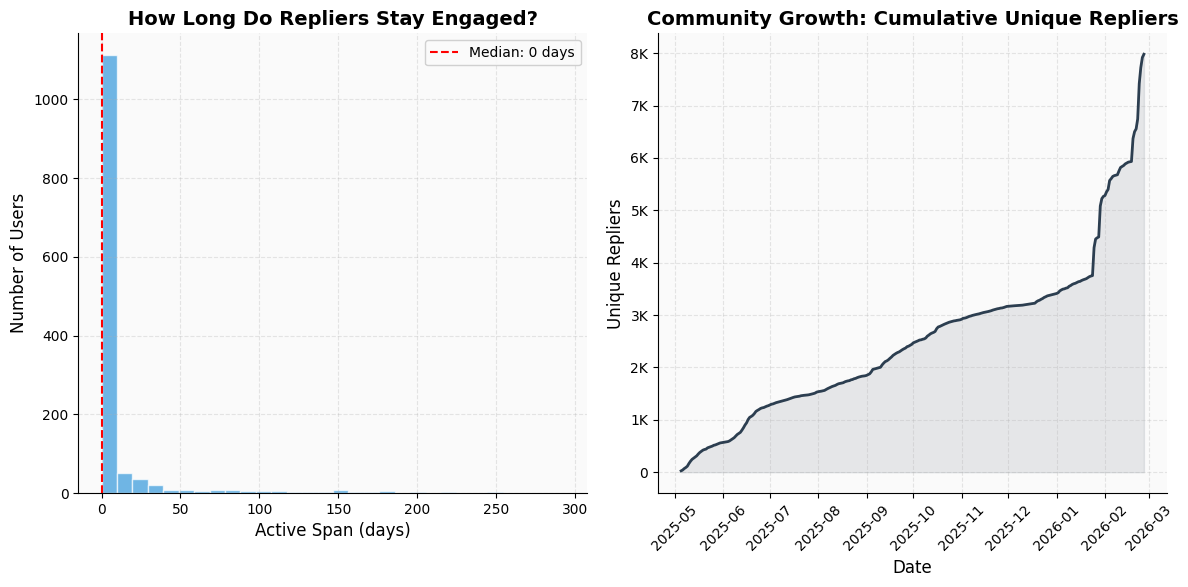


Loyalty analysis:
  One-time repliers: 6,662 (83.5%)
  Loyal users (3+ tweets, 30+ days active): 30 (0.4%)


In [16]:
# User loyalty and churn
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

# Active span distribution
active_spans = profiles[profiles['active_span_days'] > 0]['active_span_days']
axes[0].hist(active_spans, bins=30, color='#3498DB', alpha=0.7, edgecolor='white')
axes[0].axvline(active_spans.median(), color='red', linestyle='--', label=f'Median: {active_spans.median():.0f} days')
axes[0].set_title('How Long Do Repliers Stay Engaged?', fontweight='bold')
axes[0].set_xlabel('Active Span (days)')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# Cumulative unique repliers over time
replies_sorted = replies_df.sort_values('created_at')
seen_users = set()
cumulative = []
dates = []
for date, group in replies_sorted.groupby(replies_sorted['created_at'].dt.date):
    seen_users.update(group['user_name'].unique())
    cumulative.append(len(seen_users))
    dates.append(date)

axes[1].plot(dates, cumulative, color='#2C3E50', linewidth=2)
axes[1].fill_between(dates, cumulative, alpha=0.1, color='#2C3E50')
axes[1].set_title('Community Growth: Cumulative Unique Repliers', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Repliers')
format_large_numbers(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Loyalty stats
one_timers = (profiles['total_replies'] == 1).sum()
loyal = ((profiles['unique_tweets_replied'] >= 3) & (profiles['active_span_days'] >= 30)).sum()
print(f"\nLoyalty analysis:")
print(f"  One-time repliers: {one_timers:,} ({one_timers/len(profiles)*100:.1f}%)")
print(f"  Loyal users (3+ tweets, 30+ days active): {loyal:,} ({loyal/len(profiles)*100:.1f}%)")

**What does this tell us?** The active span distribution reveals whether the communities consist of persistent participants or transient visitors. High one-timer rates suggest most engagement is ephemeral — people react to a single tweet and move on. The community growth curve shows whether these political reply sections are attracting new participants over time or plateauing.

---
## 7. Bridge Users: Who Engages With Both Politicians?

Cross-profile users (replied to BOTH Trump and AOC): 10
Out of 7,980 total repliers, that's 0.13%



,User,Trump Replies,AOC Replies,Total,Followers,Sentiment,Archetype
1,grok,197,36,233,"8,104,538",neutral,casual
2,Firefish65,4,1,5,310,neutral,casual
3,Fareplease1con,1,1,2,37,negative,critic
4,ChristinaHambu4,1,1,2,"7,330",neutral,casual
5,KCKCBeliever,1,1,2,80,neutral,casual
6,Grumpy_MAGA,1,1,2,315,negative,critic
7,Kathlee61566208,1,1,2,59,neutral,casual
8,RonnieIsaacs3,1,1,2,287,neutral,casual
9,jjohnson1036915,1,1,2,13,positive,supporter
10,pal_98057,1,1,2,"5,722",positive,supporter


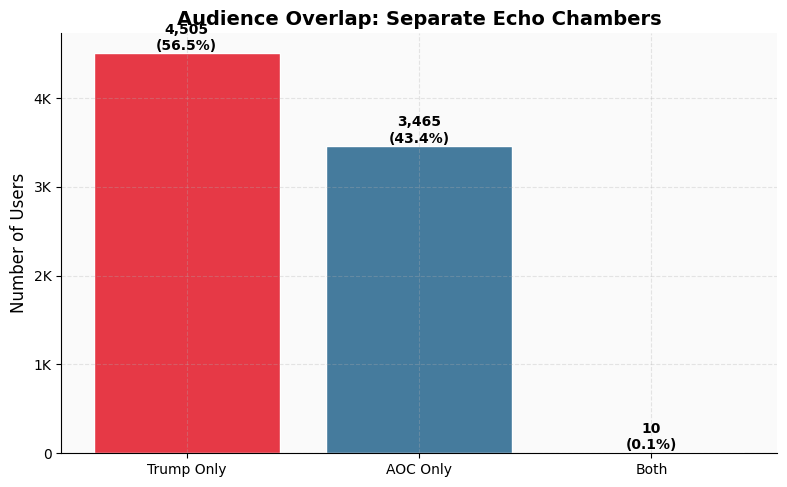

In [17]:
# Cross-profile engagement analysis
bridge_users = profiles[profiles['is_cross_profile']].sort_values('total_replies', ascending=False)

print(f"Cross-profile users (replied to BOTH Trump and AOC): {len(bridge_users)}")
print(f"Out of {len(profiles):,} total repliers, that's {len(bridge_users)/len(profiles)*100:.2f}%")
print()

if not bridge_users.empty:
    display_cols = ['user_name', 'trump_replies', 'aoc_replies', 'total_replies',
                    'user_followers_count', 'dominant_sentiment', 'archetype']
    display_df = bridge_users[display_cols].copy()
    display_df.columns = ['User', 'Trump Replies', 'AOC Replies', 'Total',
                          'Followers', 'Sentiment', 'Archetype']
    display_df['Followers'] = display_df['Followers'].apply(lambda x: f"{x:,.0f}")
    display_df = display_df.reset_index(drop=True)
    display_df.index += 1
    display(display_df)

# Audience overlap visualization
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
trump_only = (profiles['trump_replies'] > 0) & (profiles['aoc_replies'] == 0)
aoc_only = (profiles['aoc_replies'] > 0) & (profiles['trump_replies'] == 0)
both = profiles['is_cross_profile']

categories = ['Trump Only', 'AOC Only', 'Both']
counts = [trump_only.sum(), aoc_only.sum(), both.sum()]
bar_colors = [colors['trump'], colors['aoc'], '#9B59B6']

bars = ax.bar(categories, counts, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, counts):
    pct = val / len(profiles) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
           f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Audience Overlap: Separate Echo Chambers', fontweight='bold')
ax.set_ylabel('Number of Users')
format_large_numbers(ax)
plt.tight_layout()
plt.show()

**What does this tell us?** The near-total separation of audiences is one of the strongest netnographic findings in this study. With only a handful of users engaging with both politicians, the data provides empirical evidence for the **political echo chamber** phenomenon on Twitter/X. Each politician's reply section functions as its own isolated community, with almost no cross-pollination of participants.

---
## 8. Key Takeaways

### Network Structure
The reply mention network exhibits a power-law degree distribution, with a small number of hub users dominating the conversation structure. PageRank analysis reveals community-specific opinion leaders whose influence within the reply threads may not correlate with their external follower count.

### Behavioral Clusters
KMeans clustering identifies distinct behavioral groups among repliers, ranging from passive one-time commenters (the majority) to highly active, opinionated super-repliers. These clusters show different distributions across the two politicians' reply sections.

### User Archetypes
Rule-based classification identifies supporters, critics, trolls, potential bots, and influencers. The majority of repliers are casual commenters, but the small percentages of trolls and critics disproportionately shape the tone of the conversation.

### AI Participation
The presence of Grok (xAI's AI assistant) as a prolific replier in both politicians' threads raises important questions about the authenticity of online political discourse and the role of AI in shaping public conversation.

### Conversation Depth
Most first-level replies are conversational dead ends — they don't generate further discussion. True dialogue (reciprocal mentions) is rare, suggesting that political reply sections function more as broadcasting channels than genuine discourse spaces.

### Echo Chambers
The near-zero overlap between Trump and AOC replier pools provides strong empirical evidence for political echo chambers on Twitter/X. These are functionally separate communities that share a platform but not participants.